# Painel do município: um retrato de saúde com todas as bases

**A pergunta:** como está a saúde da minha cidade? Responder exige juntar
coisas que moram em sistemas diferentes — quem nasce, quem morre, quantos
leitos existem, por que se interna, o que se faz no ambulatório. Este notebook
monta esse retrato para **um município**, sempre comparado com o estado, que é
a única forma de saber se um número é bom ou ruim.

**Fonte:** IBGE, SINASC, SIM, CNES, SIH e SIA — seis bases, um município.

**Tempo estimado:** 10 a 15 minutos.

**O que você leva daqui:** um painel pronto que você adapta trocando um código
de município, com todos os indicadores lado a lado com a referência estadual.

In [2]:
%pip install pysus==2.10.6 nest_asyncio duckdb -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
con = duckdb.connect()

def mil(numero):
    "Número no padrão brasileiro: 1234567 vira 1.234.567."
    return f"{numero:,.0f}".replace(",", ".")

def reais(valor):
    return "R$ " + f"{valor:,.2f}".replace(",", "@").replace(".", ",").replace("@", ".")

painel = {}     # vai guardar cada indicador: (município, estado)

def registrar(nome, municipio, estado, unidade=""):
    painel[nome] = {"Município": municipio, "Estado": estado, "Unidade": unidade}

print("Ambiente pronto.")

Ambiente pronto.


In [4]:
# ---- Uma armadilha do catálogo, e como escapar dela --------------------
# O parâmetro state= diz onde PROCURAR, e não filtra: a PySUS devolve o arquivo
# NACIONAL ao lado do arquivo do estado. Pior, para 2025 e 2026 ela devolve
# SÓ o nacional. Pegar o primeiro da lista entrega o Brasil inteiro rotulado
# como estado — era o que este notebook fazia, e a mortalidade saía três vezes
# menor do que é.
import os

from pysus import list_files


def arquivo_da_uf(arquivos, uf, prefixo):
    """Entre os arquivos devolvidos, o DO ESTADO. Falha alto se não houver."""
    do_estado = [str(a) for a in arquivos
                 if os.path.basename(str(a)).upper().startswith(
                     f"{prefixo}{uf}".upper())]
    if not do_estado:
        nacionais = [os.path.basename(str(a)) for a in arquivos]
        raise ValueError(
            f"Não existe arquivo de {uf} para este ano: a PySUS ofereceu só "
            f"{nacionais}, que é nacional. Use ano_com_arquivo_da_uf() para "
            "escolher um ano que tenha arquivo estadual.")
    return do_estado[0].replace("\\", "/")


def ano_com_arquivo_da_uf(base, uf, prefixo, ate=None):
    """O ano mais recente COM arquivo do estado — que é também um ano fechado.

    Anos em andamento (2025, 2026) só têm o arquivo nacional, e ainda por cima
    estão incompletos: contar óbitos neles subestima tudo.
    """
    catalogo = list_files(dataset=base, state=uf)
    anos = []
    for nome, ano in zip(catalogo["name"], catalogo["year"]):
        if ano != ano:            # NaN
            continue
        if os.path.basename(str(nome)).upper().startswith(f"{prefixo}{uf}".upper()):
            if ate is None or int(ano) <= int(ate):
                anos.append(int(ano))
    if not anos:
        raise ValueError(f"Nenhum ano de {base} tem arquivo de {uf}.")
    return max(anos)

## 1. Escolha o município

O código é o do IBGE. O DATASUS usa duas formas dele: **seis dígitos** na
maioria das bases e **sete** nos arquivos do IBGE. A diferença é o dígito
verificador no fim — por isso guardamos as duas.

In [5]:
UF = "PR"
MUNICIPIO6 = "411370"       # Londrina; troque aqui
MUNICIPIO7 = MUNICIPIO6 + "0"
NOME = "Londrina"           # só para os títulos

print(f"Município: {NOME} ({MUNICIPIO6} / {MUNICIPIO7}) — {UF}")

Município: Londrina (411370 / 4113700) — PR


## 2. Quantas pessoas moram aqui

O denominador de tudo. Conferimos a integridade do arquivo antes de usar,
porque alguns anos vêm truncados na origem.

In [6]:
from pysus import ibge, list_files

def populacao_municipal(ano):
    "População por município, recusando arquivos incompletos."
    caminho = [c for c in ibge(year=ano)
               if os.path.basename(c).startswith("POPT")][0].replace("\\", "/")
    tabela = con.execute(f"SELECT * FROM read_parquet('{caminho}')").df()
    tabela["POPULACAO"] = pd.to_numeric(tabela["POPULACAO"], errors="coerce")
    tabela["uf"] = tabela["MUNIC_RES"].astype(str).str[:2]
    if tabela["uf"].nunique() < 27:
        raise ValueError(f"População de {ano} incompleta.")
    return tabela

ANO_POP = 2024
populacao = populacao_municipal(ANO_POP)
codigo_uf = MUNICIPIO6[:2]

habitantes = int(populacao.loc[populacao["MUNIC_RES"].astype(str) == MUNICIPIO7,
                               "POPULACAO"].iloc[0])
habitantes_uf = int(populacao.loc[populacao["uf"] == codigo_uf, "POPULACAO"].sum())

registrar("População", habitantes, habitantes_uf, "habitantes")
print(f"{NOME}: {mil(habitantes)} habitantes")
print(f"{UF}:  {mil(habitantes_uf)} habitantes")
print(f"O município é {habitantes / habitantes_uf * 100:.1f}% do estado.")

Londrina: 577.318 habitantes
PR:  11.824.665 habitantes
O município é 4.9% do estado.


## 3. Quem nasce

Do SINASC saem os indicadores que descrevem o começo da vida — e a maneira
como os partos acontecem.

In [7]:
from pysus import sinasc

anos_sinasc = sorted(int(a) for a in
                     list_files(dataset="sinasc", state=UF)["year"].dropna())
ANO_NASC = anos_sinasc[-1]
ANO_NASC = ano_com_arquivo_da_uf("sinasc", UF, "DN", ate=ANO_NASC)
arquivo_nasc = arquivo_da_uf(sinasc(UF, ANO_NASC), UF, "DN")
print(f"Nascimentos: ano {ANO_NASC} (o mais recente com arquivo do estado)")

def indicadores_nascimento(filtro_municipio=None):
    onde = (f"WHERE CODMUNRES = '{MUNICIPIO6}'" if filtro_municipio else "")
    return con.execute(f"""
        SELECT count(*) AS nascimentos,
               round(avg(CASE WHEN PARTO = '2' THEN 100.0
                              WHEN PARTO = '1' THEN 0.0 END), 1) AS cesarea,
               round(avg(CASE WHEN TRY_CAST(PESO AS INTEGER) BETWEEN 200 AND 7000
                              THEN CASE WHEN TRY_CAST(PESO AS INTEGER) < 2500
                                        THEN 100.0 ELSE 0.0 END END), 1) AS baixo_peso,
               round(avg(CASE WHEN TRY_CAST(SEMAGESTAC AS INTEGER) BETWEEN 15 AND 45
                              THEN CASE WHEN TRY_CAST(SEMAGESTAC AS INTEGER) < 37
                                        THEN 100.0 ELSE 0.0 END END), 1) AS prematuro,
               round(avg(CASE WHEN TRY_CAST(CONSPRENAT AS INTEGER) BETWEEN 0 AND 30
                              THEN CASE WHEN TRY_CAST(CONSPRENAT AS INTEGER) >= 6
                                        THEN 100.0 ELSE 0.0 END END), 1) AS prenatal,
               round(avg(CASE WHEN TRY_CAST(IDADEMAE AS INTEGER) BETWEEN 10 AND 55
                              THEN CASE WHEN TRY_CAST(IDADEMAE AS INTEGER) < 20
                                        THEN 100.0 ELSE 0.0 END END), 1) AS mae_adolescente
        FROM read_parquet('{arquivo_nasc}') {onde}
    """).df().iloc[0]

nasc_mun = indicadores_nascimento(True)
nasc_uf = indicadores_nascimento(False)

for chave, rotulo, unidade in [
    ("nascimentos", "Nascidos vivos", "por ano"),
    ("cesarea", "Cesáreas", "%"),
    ("prematuro", "Prematuridade", "%"),
    ("baixo_peso", "Baixo peso ao nascer", "%"),
    ("prenatal", "Pré-natal com 6+ consultas", "%"),
    ("mae_adolescente", "Mães com menos de 20 anos", "%"),
]:
    registrar(rotulo, nasc_mun[chave], nasc_uf[chave], unidade)

print(f"Ano do SINASC: {ANO_NASC}\n")
pd.DataFrame({NOME: nasc_mun, UF: nasc_uf})

Nascimentos: ano 2022 (o mais recente com arquivo do estado)
Ano do SINASC: 2022


,Londrina,PR
nascimentos,6116.0,140637.0
cesarea,63.2,64.8
baixo_peso,10.8,9.4
prematuro,12.2,11.2
prenatal,91.1,91.6
mae_adolescente,7.0,10.0


## 4. Quem morre

Do SIM saem a mortalidade geral, a infantil e o indicador de doenças crônicas.

In [8]:
from pysus import sim

anos_sim = sorted(int(a) for a in
                  list_files(dataset="sim", state=UF)["year"].dropna())
ANO_OBITO = max(a for a in anos_sim if a <= ANO_NASC) if ANO_NASC in anos_sim else anos_sim[-1]
ANO_OBITO = ano_com_arquivo_da_uf("sim", UF, "DO", ate=ANO_OBITO)
arquivo_obito = arquivo_da_uf(sim(UF, ANO_OBITO), UF, "DO")
print(f"Óbitos: ano {ANO_OBITO} (o mais recente com arquivo do estado)")

def indicadores_obito(filtro_municipio=None):
    onde = (f"WHERE CODMUNRES = '{MUNICIPIO6}'" if filtro_municipio else "")
    return con.execute(f"""
        SELECT count(*) AS obitos,
               sum(CASE WHEN substr(IDADE, 1, 1) IN ('0','1','2','3')
                         AND TIPOBITO = '2' THEN 1 ELSE 0 END) AS obitos_infantis,
               sum(CASE WHEN substr(CAUSABAS, 1, 1) = 'I' THEN 1 ELSE 0 END) AS circulatorio,
               sum(CASE WHEN substr(CAUSABAS, 1, 1) = 'C' THEN 1 ELSE 0 END) AS neoplasias,
               sum(CASE WHEN substr(CAUSABAS, 1, 1) IN ('V','W','X','Y') THEN 1 ELSE 0 END)
                   AS externas,
               sum(CASE WHEN substr(CAUSABAS, 1, 1) = 'R' THEN 1 ELSE 0 END) AS mal_definidas
        FROM read_parquet('{arquivo_obito}') {onde}
    """).df().iloc[0]

obito_mun = indicadores_obito(True)
obito_uf = indicadores_obito(False)

# nascidos vivos do mesmo ano, para a mortalidade infantil
def nascidos(ano, filtro_municipio):
    caminho = arquivo_da_uf(sinasc(UF, ano), UF, "DN")
    onde = (f"WHERE CODMUNRES = '{MUNICIPIO6}'" if filtro_municipio else "")
    return con.execute(
        f"SELECT count(*) FROM read_parquet('{caminho}') {onde}").fetchone()[0]

nasc_ano_obito_mun = nascidos(ANO_OBITO, True) if ANO_OBITO in anos_sinasc else None
nasc_ano_obito_uf = nascidos(ANO_OBITO, False) if ANO_OBITO in anos_sinasc else None

registrar("Óbitos", obito_mun["obitos"], obito_uf["obitos"], "por ano")
registrar("Mortalidade geral", round(obito_mun["obitos"] / habitantes * 1000, 1),
          round(obito_uf["obitos"] / habitantes_uf * 1000, 1), "por mil hab.")
if nasc_ano_obito_mun:
    registrar("Mortalidade infantil",
              round(obito_mun["obitos_infantis"] / nasc_ano_obito_mun * 1000, 1),
              round(obito_uf["obitos_infantis"] / nasc_ano_obito_uf * 1000, 1),
              "por mil nascidos")
for chave, rotulo in [("circulatorio", "Óbitos por causa circulatória"),
                      ("neoplasias", "Óbitos por câncer"),
                      ("externas", "Óbitos por causas externas"),
                      ("mal_definidas", "Óbitos por causa mal definida")]:
    registrar(rotulo + " (%)",
              round(obito_mun[chave] / obito_mun["obitos"] * 100, 1),
              round(obito_uf[chave] / obito_uf["obitos"] * 100, 1), "%")

print(f"Ano do SIM: {ANO_OBITO}\n")
pd.DataFrame({NOME: obito_mun, UF: obito_uf})

Óbitos: ano 2022 (o mais recente com arquivo do estado)


Ano do SIM: 2022


,Londrina,PR
obitos,4412.0,89808.0
obitos_infantis,72.0,1451.0
circulatorio,1023.0,23502.0
neoplasias,824.0,15639.0
externas,420.0,9901.0
mal_definidas,77.0,2018.0


## 5. Que rede existe aqui

Do CNES vêm os leitos e os profissionais — a capacidade instalada.

In [9]:
from pysus import cnes

ANO_CNES, MES_CNES = 2024, 6

leitos = con.execute(f"""
    SELECT CODUFMUN,
           sum(TRY_CAST(QT_EXIST AS INTEGER)) AS leitos,
           sum(TRY_CAST(QT_SUS AS INTEGER)) AS leitos_sus
    FROM read_parquet('{cnes(UF, ANO_CNES, MES_CNES, group="LT")[0].replace(chr(92) + chr(92), "/")}')
    GROUP BY 1
""").df().set_index("CODUFMUN")

profissionais = con.execute(f"""
    SELECT CODUFMUN,
           count(DISTINCT CASE WHEN CBO LIKE '225%' THEN CPF_PROF END) AS medicos,
           count(DISTINCT CASE WHEN CBO LIKE '2235%' THEN CPF_PROF END) AS enfermeiros
    FROM read_parquet('{cnes(UF, ANO_CNES, MES_CNES, group="PF")[0].replace(chr(92) + chr(92), "/")}')
    GROUP BY 1
""").df().set_index("CODUFMUN")

leitos_mun = int(leitos.loc[MUNICIPIO6, "leitos"]) if MUNICIPIO6 in leitos.index else 0
leitos_uf = int(leitos["leitos"].sum())
medicos_mun = int(profissionais.loc[MUNICIPIO6, "medicos"]) if MUNICIPIO6 in profissionais.index else 0
medicos_uf = int(profissionais["medicos"].sum())

registrar("Leitos por mil habitantes",
          round(leitos_mun / habitantes * 1000, 2),
          round(leitos_uf / habitantes_uf * 1000, 2), "por mil hab.")
registrar("Médicos por mil habitantes",
          round(medicos_mun / habitantes * 1000, 2),
          round(medicos_uf / habitantes_uf * 1000, 2), "por mil hab.")

print(f"Competência do CNES: {MES_CNES:02d}/{ANO_CNES}\n")
print(f"{NOME}: {mil(leitos_mun)} leitos, {mil(medicos_mun)} médicos")
print(f"{UF}:  {mil(leitos_uf)} leitos, {mil(medicos_uf)} médicos")

Competência do CNES: 06/2024
Londrina: 2.458 leitos, 3.107 médicos
PR:  31.125 leitos, 48.725 médicos


## 6. Por que se interna

Do SIH vêm o volume, o custo e a proporção de internações que a atenção
primária poderia ter evitado.

In [10]:
from pysus import sih

catalogo_sih = list_files(dataset="sih", state=UF)
catalogo_sih["arquivo"] = [os.path.basename(str(n).replace("\\", "/"))
                           for n in catalogo_sih["name"]]
rd = catalogo_sih[catalogo_sih["arquivo"].str.upper().str.startswith("RD")].copy()
rd["mes"] = pd.to_numeric(rd["arquivo"].str[6:8], errors="coerce")
rd = rd.dropna(subset=["year", "mes"]).sort_values(["year", "mes"])
ANO_SIH, MES_SIH = int(rd["year"].iloc[-1]), int(rd["mes"].iloc[-1])

arquivo_sih = [c for c in sih(UF, ANO_SIH, MES_SIH)
               if os.path.basename(c).upper().startswith("RD")][0].replace("\\", "/")

ICSAP_PREFIXOS = [
    "A33","A34","A35","A36","A37","A95","B05","B06","B16","B26","B77","A19",
    "E86","A00","A01","A02","A03","A04","A05","A06","A07","A08","A09","D50",
    "H66","J00","J01","J02","J03","J06","J31","J13","J14","J18","J45","J46",
    "J20","J21","J40","J41","J42","J43","J44","J47","I10","I11","I20","I50",
    "J81","I63","I64","I65","I66","I67","I69","G45","G46","E10","E11","E12",
    "E13","E14","G40","G41","N10","N11","N12","N30","N34","A46","L01","L02",
    "L03","L04","L08","N70","N71","N72","N73","N75","N76","K25","K26","K27",
    "K28","O23","A50",
]
lista_icsap = ", ".join(f"'{p}'" for p in ICSAP_PREFIXOS)

def indicadores_internacao(filtro_municipio):
    onde = (f"AND MUNIC_RES = '{MUNICIPIO6}'" if filtro_municipio else "")
    return con.execute(f"""
        SELECT count(*) AS internacoes,
               round(avg(TRY_CAST(DIAS_PERM AS DOUBLE)), 1) AS permanencia,
               round(avg(CASE WHEN MORTE = '1' THEN 100.0 ELSE 0.0 END), 2) AS letalidade,
               sum(TRY_CAST(VAL_TOT AS DOUBLE)) AS valor,
               round(avg(CASE WHEN substr(DIAG_PRINC, 1, 3) IN ({lista_icsap})
                              THEN 100.0 ELSE 0.0 END), 1) AS icsap,
               round(avg(CASE WHEN MUNIC_RES <> MUNIC_MOV THEN 100.0 ELSE 0.0 END), 1)
                   AS fora_do_municipio
        FROM read_parquet('{arquivo_sih}')
        WHERE substr(DIAG_PRINC, 1, 1) <> 'O' {onde}
    """).df().iloc[0]

sih_mun = indicadores_internacao(True)
sih_uf = indicadores_internacao(False)

registrar("Internações sensíveis à atenção primária",
          sih_mun["icsap"], sih_uf["icsap"], "%")
registrar("Internações fora do município de residência",
          sih_mun["fora_do_municipio"], sih_uf["fora_do_municipio"], "%")
registrar("Permanência média", sih_mun["permanencia"], sih_uf["permanencia"], "dias")
registrar("Letalidade hospitalar", sih_mun["letalidade"], sih_uf["letalidade"], "%")

print(f"Competência do SIH: {MES_SIH:02d}/{ANO_SIH} "
      f"(o grupo RD é publicado em poucos meses)\n")
print(f"{NOME}: {mil(sih_mun['internacoes'])} internações, "
      f"{reais(sih_mun['valor'])}")
print(f"{UF}:  {mil(sih_uf['internacoes'])} internações, {reais(sih_uf['valor'])}")

Competência do SIH: 06/2026 (o grupo RD é publicado em poucos meses)
Londrina: 3.195 internações, R$ 8.389.966,25
PR:  84.420 internações, R$ 198.890.315,29


## 7. O painel

Todos os indicadores num quadro só, com a razão entre o município e o estado.
É essa coluna final que dirige o olhar: quanto mais longe de 1, mais o
município se afasta da referência — para melhor ou para pior.

In [11]:
quadro = pd.DataFrame(painel).T
quadro["Município"] = pd.to_numeric(quadro["Município"], errors="coerce")
quadro["Estado"] = pd.to_numeric(quadro["Estado"], errors="coerce")
quadro["Razão"] = (quadro["Município"] / quadro["Estado"]).round(2)

# nos totais absolutos a razão não faz sentido — só nas taxas e percentuais
absolutos = quadro["Unidade"].isin(["habitantes", "por ano"])
quadro.loc[absolutos, "Razão"] = None

quadro[["Município", "Estado", "Unidade", "Razão"]]

,Município,Estado,Unidade,Razão
População,577318.00,11824665.00,habitantes,NaN
Nascidos vivos,6116.00,140637.00,por ano,NaN
Cesáreas,63.20,64.80,%,0.98
Prematuridade,12.20,11.20,%,1.09
Baixo peso ao nascer,10.80,9.40,%,1.15
Pré-natal com 6+ consultas,91.10,91.60,%,0.99
Mães com menos de 20 anos,7.00,10.00,%,0.70
Óbitos,4412.00,89808.00,por ano,NaN
Mortalidade geral,7.60,7.60,por mil hab.,1.00
Mortalidade infantil,11.80,10.30,por mil nascidos,1.15


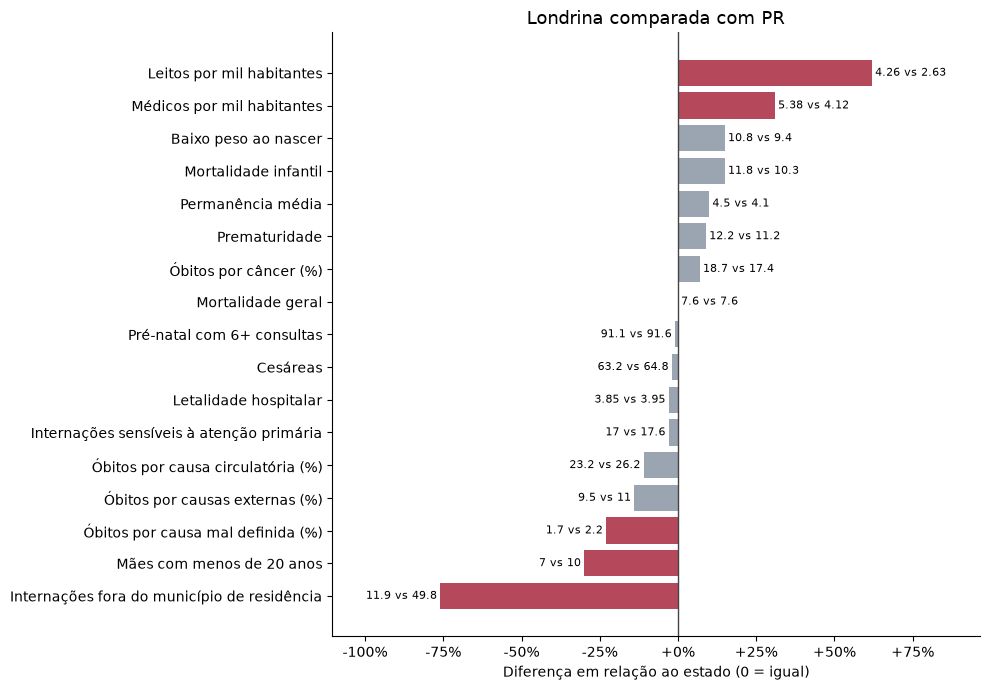

In [12]:
comparaveis = quadro[quadro["Razão"].notna()].copy()
comparaveis = comparaveis.sort_values("Razão")

figura, eixo = plt.subplots(figsize=(10, 7))
cores = ["#b5495b" if abs(r - 1) > 0.15 else "#9aa5b1" for r in comparaveis["Razão"]]
eixo.barh(comparaveis.index, comparaveis["Razão"] - 1, color=cores)
eixo.axvline(0, color="#444", linewidth=1)

for indice, (nome, linha) in enumerate(comparaveis.iterrows()):
    deslocamento = 0.01 if linha["Razão"] >= 1 else -0.01
    alinhamento = "left" if linha["Razão"] >= 1 else "right"
    eixo.text(linha["Razão"] - 1 + deslocamento, indice,
              f"{linha['Município']:g} vs {linha['Estado']:g}",
              va="center", ha=alinhamento, fontsize=8)

eixo.set_xlabel("Diferença em relação ao estado (0 = igual)")
eixo.set_title(f"{NOME} comparada com {UF}", fontsize=13)
eixo.xaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
eixo.spines[["top", "right"]].set_visible(False)
eixo.margins(x=0.25)
plt.tight_layout()
plt.show()

### Como ler este gráfico

Barras à direita: o indicador é **maior** no município que no estado. À
esquerda, menor. Nenhuma das duas coisas é boa ou ruim por si — depende do
indicador.

Mais leitos e mais médicos por habitante costumam ser bom sinal, e são
esperados em cidades-polo, que atendem toda uma região. Já uma proporção alta
de internações por condições sensíveis à atenção primária aponta para o
contrário: a rede básica não está segurando o que deveria.

E há um par que precisa ser lido junto: **internações fora do município** e
**leitos por habitante**. Um município com poucos leitos e muita gente
internando fora não tem um problema hospitalar — tem um lugar definido na
regionalização, e é assim que o SUS foi desenhado. O problema aparece quando
sair da cidade não é escolha, e sim a única opção para o que deveria ser
resolvido perto de casa.

## 8. Conferindo com a realidade

In [13]:
print("Verificações de sanidade\n")
print(f"1. População do município encontrada?        {mil(habitantes)} "
      f"({'sim' if habitantes > 0 else 'ATENÇÃO'})")
print(f"2. Cesárea entre 30% e 90%?                  {nasc_mun['cesarea']}% "
      f"({'sim' if 30 < nasc_mun['cesarea'] < 90 else 'ATENÇÃO'})")
print(f"3. Mortalidade geral entre 4 e 12 por mil?   "
      f"{quadro.loc['Mortalidade geral', 'Município']} "
      f"({'sim' if 4 < quadro.loc['Mortalidade geral', 'Município'] < 12 else 'ATENÇÃO'})")
print(f"4. ICSAP entre 5% e 35%?                     {sih_mun['icsap']}% "
      f"({'sim' if 5 < sih_mun['icsap'] < 35 else 'ATENÇÃO'})")
print(f"5. Causas mal definidas abaixo de 10%?       "
      f"{quadro.loc['Óbitos por causa mal definida (%)', 'Município']}% "
      f"({'sim' if quadro.loc['Óbitos por causa mal definida (%)', 'Município'] < 10 else 'ATENÇÃO'})")
print()
print("Uma ressalva de método: municípios pequenos produzem indicadores")
print("instáveis. Se o seu tiver menos de 300 nascimentos por ano, acumule três")
print("anos antes de comparar — o notebook de mortalidade infantil mostra como.")

Verificações de sanidade
1. População do município encontrada?        577.318 (sim)
2. Cesárea entre 30% e 90%?                  63.2% (sim)
3. Mortalidade geral entre 4 e 12 por mil?   7.6 (sim)
4. ICSAP entre 5% e 35%?                     17.0% (sim)
5. Causas mal definidas abaixo de 10%?       1.7% (sim)
Uma ressalva de método: municípios pequenos produzem indicadores
instáveis. Se o seu tiver menos de 300 nascimentos por ano, acumule três
anos antes de comparar — o notebook de mortalidade infantil mostra como.


## 9. Como adaptar

| Você quer | Mude isto |
|---|---|
| Outro município | `MUNICIPIO6`, `MUNICIPIO7` e `NOME` |
| Outro estado | `UF` — e um código de município daquele estado |
| Comparar dois municípios | rode o notebook duas vezes e junte os quadros |
| Comparar com a região de saúde | use o campo `REGSAUDE` do CNES para descobrir quais municípios a compõem |
| Acompanhar no tempo | rode em laço sobre vários anos e guarde `quadro` de cada um |
| Acrescentar indicadores | some entradas com `registrar(nome, municipio, estado, unidade)` |

### O que vale levar

A estrutura: **cada indicador calculado duas vezes, para o município e para o
estado, com o mesmo código.** É isso que evita a armadilha de olhar um número
isolado e não saber se ele é alto ou baixo.

Os notebooks aprofundados de cada base explicam a fundo cada indicador que
aparece aqui resumido.

---

*Exemplo do repositório [PySusNoCode-Exemplos](https://github.com/cartaproale/PySusNoCode-Exemplos).
Dados: IBGE, SINASC, SIM, CNES e SIH, via biblioteca [PySUS](https://github.com/AlertaDengue/PySUS).
Notebook executado de verdade antes de publicado.*